In [3]:
!pip install pandas numpy scikit-learn xgboost
!pip install imbalanced-learn matplotlib seaborn
!pip install fastapi uvicorn joblib boto3 sagemaker
!pip install python-multipart requests

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
# Load data
df = pd.read_csv('../data/creditcard.csv')

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud Percentage: {df['Class'].mean()*100:.4f}%")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Percentage: 0.1727%

Missing Values: 0


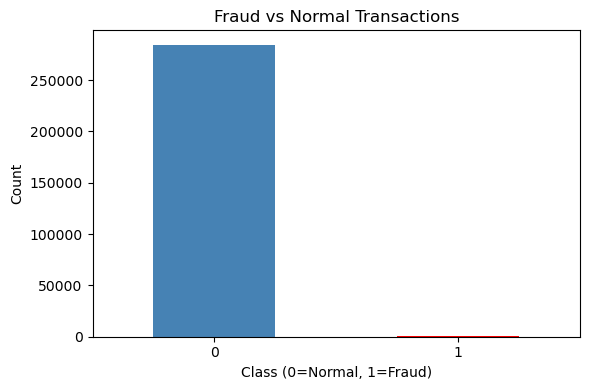

Saved: output/class_distribution.png


In [6]:
# Visualize class imbalance
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['steelblue','red'])
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../output/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/class_distribution.png")

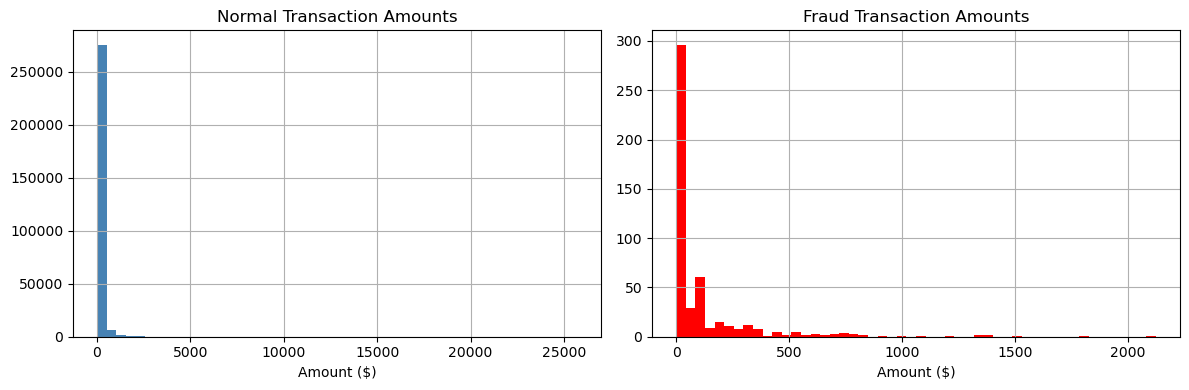

Saved: output/amount_distribution.png


In [7]:
# Visualize Amount distribution
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
df[df['Class']==0]['Amount'].hist(bins=50, color='steelblue')
plt.title('Normal Transaction Amounts')
plt.xlabel('Amount ($)')

plt.subplot(1,2,2)
df[df['Class']==1]['Amount'].hist(bins=50, color='red')
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount ($)')

plt.tight_layout()
plt.savefig('../output/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/amount_distribution.png")

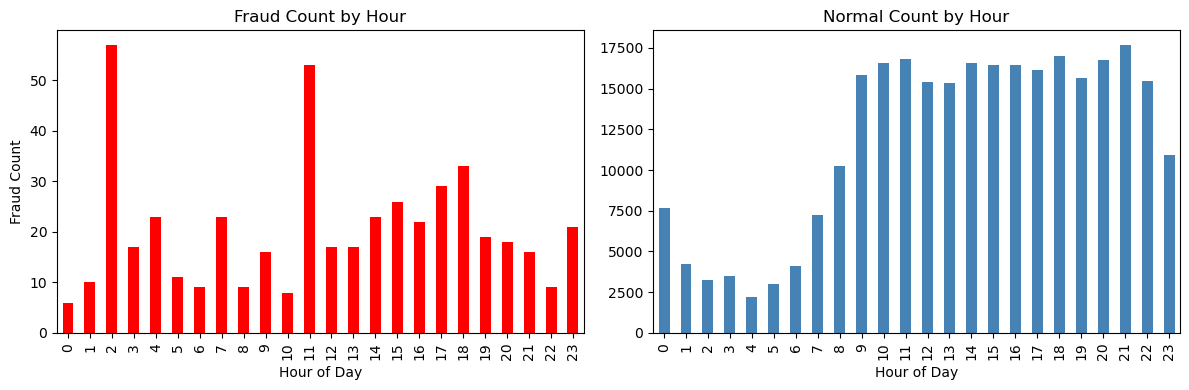

Saved: output/fraud_by_hour.png


In [8]:
# Visualize fraud by hour
df['hour_temp'] = (df['Time'] / 3600).astype(int) % 24

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
df[df['Class']==1].groupby('hour_temp').size().plot(kind='bar', color='red')
plt.title('Fraud Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Count')

plt.subplot(1,2,2)
df[df['Class']==0].groupby('hour_temp').size().plot(kind='bar', color='steelblue')
plt.title('Normal Count by Hour')
plt.xlabel('Hour of Day')

plt.tight_layout()
plt.savefig('../output/fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/fraud_by_hour.png")

df.drop('hour_temp', axis=1, inplace=True)

In [9]:
# Feature Engineering
# Scale Amount
scaler_amount = StandardScaler()
df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])

# Scale Time
scaler_time = StandardScaler()
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])

# New feature: hour of day
df['hour'] = (df['Time'] / 3600).astype(int) % 24

# New feature: log amount
df['log_amount'] = np.log1p(df['Amount'])

# Drop original columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

print("Features after engineering:")
print(df.columns.tolist())
print("\nShape:", df.shape)

Features after engineering:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled', 'hour', 'log_amount']

Shape: (284807, 33)


In [14]:
import os
import joblib

os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)

joblib.dump(scaler_amount, 'models/scaler_amount.pkl')
joblib.dump(scaler_time, 'models/scaler_time.pkl')

print("Scalers saved to models/")

Scalers saved to models/


In [15]:
# train test split
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Training fraud cases: {y_train.sum()}")
print(f"Test fraud cases:     {y_test.sum()}")

X_train shape: (227845, 32)
X_test shape:  (56962, 32)
Training fraud cases: 394
Test fraud cases:     98


In [16]:
# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [18]:
#  Train XGBoost
import xgboost as xgb

neg = (y_train_sm == 0).sum()
pos = (y_train_sm == 1).sum()
scale = neg / pos
print(f"Scale pos weight: {scale:.2f}")

print("\nTraining XGBoost model...")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    early_stopping_rounds=30,    # moved here from fit()
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nModel training complete.")

Scale pos weight: 1.00

Training XGBoost model...
[0]	validation_0-aucpr:0.50714
[50]	validation_0-aucpr:0.80299
[100]	validation_0-aucpr:0.83266
[150]	validation_0-aucpr:0.84528
[200]	validation_0-aucpr:0.86342
[250]	validation_0-aucpr:0.86770
[299]	validation_0-aucpr:0.87030

Model training complete.


In [19]:
# Evaluate model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal','Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.77      0.86      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9847
Average Precision: 0.8705


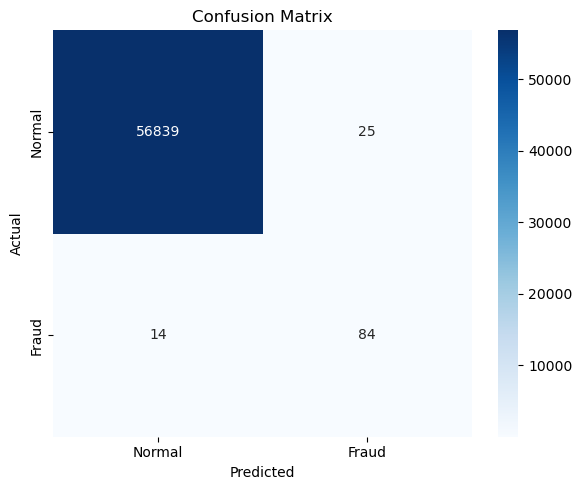

True Negatives:  56839
False Positives: 25
False Negatives: 14
True Positives:  84


In [20]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('output/confusion_matrix.png')
plt.show()

print(f"True Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

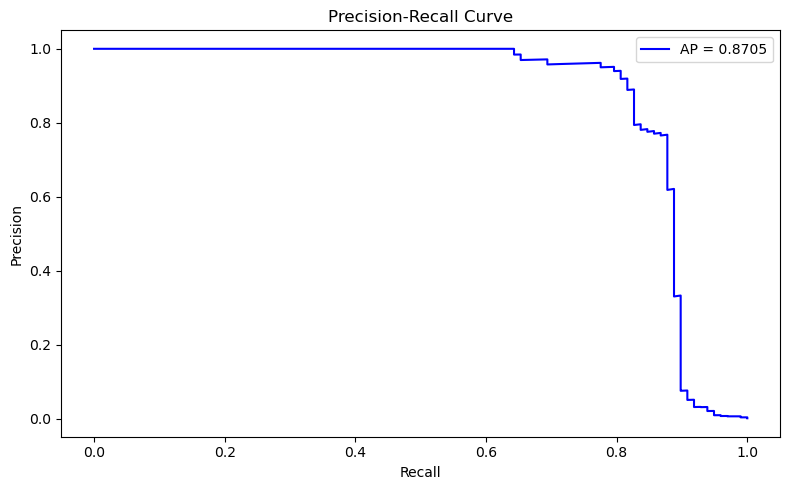

In [21]:
# Plot Precision Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='blue', label=f'AP = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('output/precision_recall_curve.png')
plt.show()

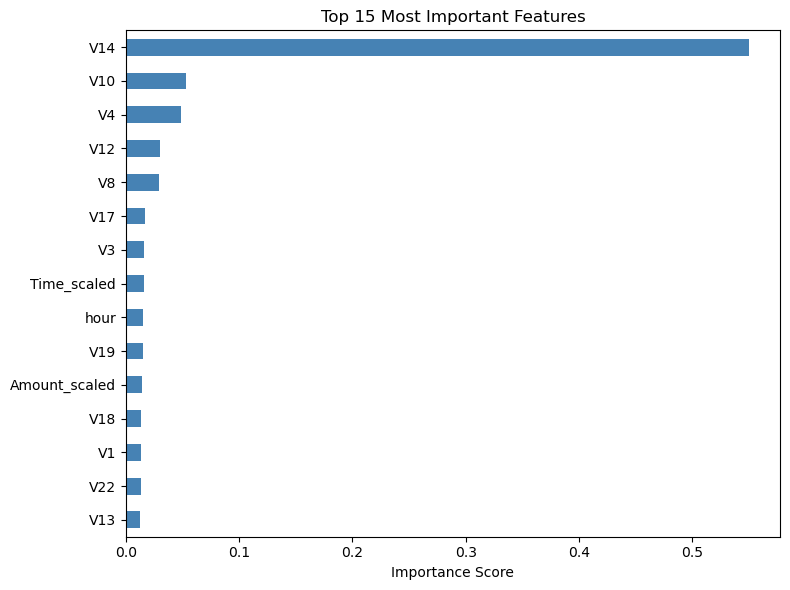

In [22]:
# Plot feature importance
feat_imp = pd.Series(
    model.feature_importances_,
    index=X_test.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('output/feature_importance.png')
plt.show()

In [23]:
# Save model
joblib.dump(model, 'models/fraud_model.pkl')
print("Model saved to models/fraud_model.pkl")

Model saved to models/fraud_model.pkl


In [24]:
# Save predictions for Power BI
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted_class': y_pred,
    'predicted_prob': y_prob,
    'risk_level': [
        'HIGH' if p > 0.7 else 'MEDIUM' if p > 0.4 else 'LOW'
        for p in y_prob
    ],
    'hour': X_test['hour'].values,
    'log_amount': X_test['log_amount'].values
})

results_df['transaction_date'] = pd.date_range(
    start='2024-01-01',
    periods=len(results_df),
    freq='T'
)
results_df['week'] = results_df['transaction_date'].dt.isocalendar().week
results_df['month'] = results_df['transaction_date'].dt.month

results_df.to_csv('output/predictions.csv', index=False)
print(f"Predictions saved: {len(results_df)} rows")
print(f"Fraud flagged: {results_df['predicted_class'].sum()}")
results_df.head()

Predictions saved: 56962 rows
Fraud flagged: 109


,actual,predicted_class,predicted_prob,risk_level,hour,log_amount,transaction_date,week,month
0,0,0,1.611162e-06,LOW,20,3.178054,2024-01-01 00:00:00,1,1
1,0,0,2.249863e-07,LOW,5,2.553344,2024-01-01 00:01:00,1,1
2,0,0,1.741985e-05,LOW,0,4.344714,2024-01-01 00:02:00,1,1
3,0,0,1.186912e-07,LOW,15,0.688135,2024-01-01 00:03:00,1,1
4,0,0,8.287745e-05,LOW,10,0.916291,2024-01-01 00:04:00,1,1


In [25]:
# Test prediction on a single transaction
# Load model and scalers
loaded_model = joblib.load('models/fraud_model.pkl')
loaded_scaler_amount = joblib.load('models/scaler_amount.pkl')
loaded_scaler_time = joblib.load('models/scaler_time.pkl')

# Sample transaction
sample = {
    'V1': -1.3598071336738, 'V2': -0.0727811733098497,
    'V3': 2.53634673796914, 'V4': 1.37815522427443,
    'V5': -0.338320769942518, 'V6': 0.462387777762292,
    'V7': 0.239598554061257, 'V8': 0.0986979012610507,
    'V9': 0.363786969611213, 'V10': 0.0907941719789316,
    'V11': -0.551599533260813, 'V12': -0.617800855762348,
    'V13': -0.991389847235408, 'V14': -0.311169353699879,
    'V15': 1.46817697209427, 'V16': -0.470400525259478,
    'V17': 0.207971241929242, 'V18': 0.0257905801985591,
    'V19': 0.403992960255733, 'V20': 0.251412098239705,
    'V21': -0.018306777944153, 'V22': 0.277837575558899,
    'V23': -0.110473910188767, 'V24': 0.0669280749146731,
    'V25': 0.128539358273528, 'V26': -0.189114843888824,
    'V27': 0.133558376740387, 'V28': -0.0210530534538215,
    'Amount': 149.62,
    'Time': 0.0
}

# Preprocess
amount = sample.pop('Amount')
time_val = sample.pop('Time')
sample['Amount_scaled'] = loaded_scaler_amount.transform([[amount]])[0][0]
sample['Time_scaled'] = loaded_scaler_time.transform([[time_val]])[0][0]
sample['hour'] = int(time_val / 3600) % 24
sample['log_amount'] = np.log1p(amount)

features = np.array(list(sample.values())).reshape(1, -1)
prob = loaded_model.predict_proba(features)[0][1]

print(f"Fraud Probability : {prob:.4f}")
print(f"Is Fraud          : {prob > 0.5}")
print(f"Risk Level        : {'HIGH' if prob > 0.7 else 'MEDIUM' if prob > 0.4 else 'LOW'}")

Fraud Probability : 0.0000
Is Fraud          : False
Risk Level        : LOW


In [26]:
# Run FastAPI using threading
import threading
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from datetime import datetime

app = FastAPI(title="Fraud Detection API")

m = joblib.load('models/fraud_model.pkl')
sa = joblib.load('models/scaler_amount.pkl')
st = joblib.load('models/scaler_time.pkl')

class Transaction(BaseModel):
    V1:float; V2:float; V3:float; V4:float; V5:float
    V6:float; V7:float; V8:float; V9:float; V10:float
    V11:float; V12:float; V13:float; V14:float; V15:float
    V16:float; V17:float; V18:float; V19:float; V20:float
    V21:float; V22:float; V23:float; V24:float; V25:float
    V26:float; V27:float; V28:float
    Amount:float; Time:float

@app.get("/health")
def health():
    return {"status":"ok","timestamp":datetime.now().isoformat()}

@app.post("/predict")
def predict(txn: Transaction):
    data = dict(txn)
    amount = data.pop('Amount')
    time_val = data.pop('Time')
    data['Amount_scaled'] = sa.transform([[amount]])[0][0]
    data['Time_scaled'] = st.transform([[time_val]])[0][0]
    data['hour'] = int(time_val / 3600) % 24
    data['log_amount'] = np.log1p(amount)
    features = np.array(list(data.values())).reshape(1,-1)
    prob = float(m.predict_proba(features)[0][1])
    return {
        "fraud_probability": round(prob,4),
        "is_fraud": prob > 0.5,
        "risk_level": "HIGH" if prob>0.7 else "MEDIUM" if prob>0.4 else "LOW",
        "timestamp": datetime.now().isoformat()
    }

def run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="error")

thread = threading.Thread(target=run, daemon=True)
thread.start()

print("API is running at http://localhost:8000")
print("Test it at http://localhost:8000/docs")

API is running at http://localhost:8000
Test it at http://localhost:8000/docs


In [27]:
# Test the API 
import requests
import json

url = "http://localhost:8000/predict"

transaction = {
    "V1":-1.3598071336738,"V2":-0.0727811733098497,
    "V3":2.53634673796914,"V4":1.37815522427443,
    "V5":-0.338320769942518,"V6":0.462387777762292,
    "V7":0.239598554061257,"V8":0.0986979012610507,
    "V9":0.363786969611213,"V10":0.0907941719789316,
    "V11":-0.551599533260813,"V12":-0.617800855762348,
    "V13":-0.991389847235408,"V14":-0.311169353699879,
    "V15":1.46817697209427,"V16":-0.470400525259478,
    "V17":0.207971241929242,"V18":0.0257905801985591,
    "V19":0.403992960255733,"V20":0.251412098239705,
    "V21":-0.018306777944153,"V22":0.277837575558899,
    "V23":-0.110473910188767,"V24":0.0669280749146731,
    "V25":0.128539358273528,"V26":-0.189114843888824,
    "V27":0.133558376740387,"V28":-0.0210530534538215,
    "Amount":149.62,"Time":0.0
}

response = requests.post(url, json=transaction)
print(json.dumps(response.json(), indent=2))

{
  "fraud_probability": 0.0,
  "is_fraud": false,
  "risk_level": "LOW",
  "timestamp": "2026-06-19T20:39:21.233015"
}


In [28]:
import subprocess

# Replace with your actual keys
ACCESS_KEY = "YOUR_AWS_ACCESS_KEY"
SECRET_KEY = "YOUR_AWS_ACCESS_KEY"
REGION = "us-east-2"  # Ohio — matches your console

subprocess.run(['aws', 'configure', 'set', 'aws_access_key_id', ACCESS_KEY])
subprocess.run(['aws', 'configure', 'set', 'aws_secret_access_key', SECRET_KEY])
subprocess.run(['aws', 'configure', 'set', 'default.region', REGION])
subprocess.run(['aws', 'configure', 'set', 'default.output', 'json'])

print("AWS configured.")

AWS configured.


In [29]:
import boto3

REGION = "us-east-2"

sts = boto3.client('sts', region_name=REGION)
identity = sts.get_caller_identity()

print("Connected successfully.")
print(f"Account ID: {identity['Account']}")
print(f"User: {identity['Arn']}")

Connected successfully.
Account ID: 182844679693
User: arn:aws:iam::182844679693:root


In [15]:
import boto3

BUCKET_NAME = "fraud-detection-navya" 
REGION = "us-east-2"

s3 = boto3.client('s3', region_name=REGION)

try:
    s3.create_bucket(
        Bucket=BUCKET_NAME,
        CreateBucketConfiguration={
            'LocationConstraint': REGION
        }
    )
    print(f"Bucket created: {BUCKET_NAME}")
except Exception as e:
    print(f"Error: {e}")

# Verify
response = s3.list_buckets()
print("\nYour S3 buckets:")
for b in response['Buckets']:
    print(f"  - {b['Name']}")

Error: An error occurred (BucketAlreadyOwnedByYou) when calling the CreateBucket operation: Your previous request to create the named bucket succeeded and you already own it.

Your S3 buckets:
  - fraud-detection-navya


In [31]:
import boto3
import tarfile
import os

s3 = boto3.client('s3', region_name=REGION)

# Package model files
print("Packaging model files...")
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("models/fraud_model.pkl",   arcname="fraud_model.pkl")
    tar.add("models/scaler_amount.pkl", arcname="scaler_amount.pkl")
    tar.add("models/scaler_time.pkl",   arcname="scaler_time.pkl")

size = os.path.getsize("model.tar.gz") / 1024 / 1024
print(f"Package created: model.tar.gz ({size:.2f} MB)")

# Upload model
print("\nUploading model to S3...")
s3.upload_file(
    "model.tar.gz",
    BUCKET_NAME,
    "fraud-detection/model.tar.gz"
)
print("Model uploaded.")

# Upload predictions CSV
print("\nUploading predictions CSV...")
s3.upload_file(
    "output/predictions.csv",
    BUCKET_NAME,
    "fraud-detection/predictions.csv"
)
print("Predictions uploaded.")

# Verify
print("\nFiles in S3 bucket:")
response = s3.list_objects_v2(
    Bucket=BUCKET_NAME,
    Prefix="fraud-detection/"
)
for obj in response['Contents']:
    size = obj['Size'] / 1024
    print(f"  {obj['Key']} — {size:.1f} KB")

Packaging model files...
Package created: model.tar.gz (0.30 MB)

Uploading model to S3...
Model uploaded.

Uploading predictions CSV...
Predictions uploaded.

Files in S3 bucket:
  fraud-detection/model.tar.gz — 308.1 KB
  fraud-detection/predictions.csv — 3764.4 KB


In [32]:
import os

inference_script = '''
import joblib
import numpy as np
import os
import json

def model_fn(model_dir):
    model = joblib.load(os.path.join(model_dir, "fraud_model.pkl"))
    scaler_amount = joblib.load(os.path.join(model_dir, "scaler_amount.pkl"))
    scaler_time = joblib.load(os.path.join(model_dir, "scaler_time.pkl"))
    return {
        "model": model,
        "scaler_amount": scaler_amount,
        "scaler_time": scaler_time
    }

def input_fn(request_body, request_content_type):
    if request_content_type == "application/json":
        return json.loads(request_body)
    raise ValueError(f"Unsupported content type: {request_content_type}")

def predict_fn(input_data, model_dict):
    model = model_dict["model"]
    scaler_amount = model_dict["scaler_amount"]
    scaler_time = model_dict["scaler_time"]

    data = input_data.copy()
    amount = data.pop("Amount")
    time_val = data.pop("Time")

    data["Amount_scaled"] = scaler_amount.transform([[amount]])[0][0]
    data["Time_scaled"] = scaler_time.transform([[time_val]])[0][0]
    data["hour"] = int(time_val / 3600) % 24
    data["log_amount"] = float(np.log1p(amount))

    features = np.array(list(data.values())).reshape(1, -1)
    prob = float(model.predict_proba(features)[0][1])
    return prob

def output_fn(prediction, response_content_type):
    prob = prediction
    if prob > 0.7:
        risk = "HIGH"
        action = "Block transaction immediately"
    elif prob > 0.4:
        risk = "MEDIUM"
        action = "Flag for manual review"
    else:
        risk = "LOW"
        action = "Allow transaction"

    return json.dumps({
        "fraud_probability": round(prob, 4),
        "is_fraud": prob > 0.5,
        "risk_level": risk,
        "recommended_action": action
    })
'''

os.makedirs('src', exist_ok=True)
with open('src/inference.py', 'w') as f:
    f.write(inference_script)

print("Inference script saved to src/inference.py")

# Upload to S3
s3 = boto3.client('s3', region_name=REGION)
s3.upload_file(
    "src/inference.py",
    BUCKET_NAME,
    "fraud-detection/inference.py"
)
print("Inference script uploaded to S3")

Inference script saved to src/inference.py
Inference script uploaded to S3


In [33]:
import boto3
import json

iam = boto3.client('iam')
ROLE_NAME = "FraudDetectionSageMakerRole"

trust_policy = {
    "Version": "2012-10-17",
    "Statement": [{
        "Effect": "Allow",
        "Principal": {"Service": "sagemaker.amazonaws.com"},
        "Action": "sts:AssumeRole"
    }]
}

try:
    role = iam.create_role(
        RoleName=ROLE_NAME,
        AssumeRolePolicyDocument=json.dumps(trust_policy),
        Description="SageMaker role for fraud detection"
    )
    ROLE_ARN = role['Role']['Arn']
    print(f"Role created: {ROLE_ARN}")

    iam.attach_role_policy(
        RoleName=ROLE_NAME,
        PolicyArn="arn:aws:iam::aws:policy/AmazonSageMakerFullAccess"
    )
    print("SageMaker policy attached.")

    iam.attach_role_policy(
        RoleName=ROLE_NAME,
        PolicyArn="arn:aws:iam::aws:policy/AmazonS3FullAccess"
    )
    print("S3 policy attached.")

    import time
    print("Waiting 15 seconds for role to be ready...")
    time.sleep(15)

except iam.exceptions.EntityAlreadyExistsException:
    role = iam.get_role(RoleName=ROLE_NAME)
    ROLE_ARN = role['Role']['Arn']
    print(f"Role already exists: {ROLE_ARN}")

print(f"\nRole ARN: {ROLE_ARN}")

Role created: arn:aws:iam::182844679693:role/FraudDetectionSageMakerRole
SageMaker policy attached.
S3 policy attached.
Waiting 15 seconds for role to be ready...

Role ARN: arn:aws:iam::182844679693:role/FraudDetectionSageMakerRole


In [35]:
!pip install sagemaker --upgrade

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   -------- ------------------------------- 0.3/1.3 MB ? eta -:--:--
   ---------------- ----------------------- 0.5/1.3 MB 1.7 MB/s eta 0:00:01
   -------------------------------- ------- 1.0/1.3 MB 2.0 MB/s eta 0:00:01
   -------------------------------- ------- 1.0/1.3 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.3 MB/s  0:00:00

  Attempting uninstall: sagemaker-core

    Found existing installation: sagemaker-core 2.13.1

   ---------------------------------------- 0/5 [sagemaker-core]
   ---------------------------------------- 0/5 [sagemaker-core]
   ---------------------------------------- 0/5 [sagemaker-core]
    Uninstalling sagemaker-core-2.13.1:
   ---------------------------------------- 0/5 [sagemaker-core]
   ---------------------------------------- 0/5 [sagemaker-core]
      Successfully uninstalled sagemaker-core-2.13.1
   ---------------------------------------- 0/

In [3]:
import sys
print(sys.executable)

C:\Users\navya\anaconda3\python.exe


In [4]:
import sys
import subprocess

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'sagemaker', '--upgrade'],
    capture_output=True,
    text=True
)
print(result.stdout[-3000:])
print("Done.")

2.0.0->sagemaker-serve<2.0.0,>=1.14.0->sagemaker) (3.20.0)

Done.


In [1]:
import os
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: C:\Users\navya\OneDrive\Desktop\Fraud Detection


In [2]:
import boto3

REGION = "us-east-2"
BUCKET_NAME = "fraud-detection-navya"
ENDPOINT_NAME = "fraud-detection-endpoint"

iam = boto3.client('iam')
role = iam.get_role(RoleName='FraudDetectionSageMakerRole')
ROLE_ARN = role['Role']['Arn']

print(f"Region:  {REGION}")
print(f"Bucket:  {BUCKET_NAME}")
print(f"Role:    {ROLE_ARN}")

Region:  us-east-2
Bucket:  fraud-detection-navya
Role:    arn:aws:iam::182844679693:role/FraudDetectionSageMakerRole


In [10]:
import os

# This is the corrected inference script
# Fixed to handle XGBoost model loaded with joblib
inference_script = """
import joblib
import numpy as np
import os
import json
import logging

logger = logging.getLogger(__name__)

def model_fn(model_dir):
    logger.info(f"Loading model from {model_dir}")
    logger.info(f"Files in model dir: {os.listdir(model_dir)}")
    
    model = joblib.load(os.path.join(model_dir, "fraud_model.pkl"))
    scaler_amount = joblib.load(os.path.join(model_dir, "scaler_amount.pkl"))
    scaler_time = joblib.load(os.path.join(model_dir, "scaler_time.pkl"))
    
    logger.info("Model loaded successfully.")
    return {
        "model": model,
        "scaler_amount": scaler_amount,
        "scaler_time": scaler_time
    }

def input_fn(request_body, content_type="application/json"):
    logger.info(f"Received request. Content type: {content_type}")
    if content_type == "application/json":
        data = json.loads(request_body)
        return data
    raise ValueError(f"Unsupported content type: {content_type}")

def predict_fn(input_data, model_dict):
    model = model_dict["model"]
    scaler_amount = model_dict["scaler_amount"]
    scaler_time = model_dict["scaler_time"]

    data = input_data.copy()
    
    amount = float(data.pop("Amount", 0))
    time_val = float(data.pop("Time", 0))

    data["Amount_scaled"] = float(scaler_amount.transform([[amount]])[0][0])
    data["Time_scaled"] = float(scaler_time.transform([[time_val]])[0][0])
    data["hour"] = int(time_val / 3600) % 24
    data["log_amount"] = float(np.log1p(amount))

    feature_values = [float(v) for v in data.values()]
    features = np.array(feature_values).reshape(1, -1)
    
    prob = float(model.predict_proba(features)[0][1])
    logger.info(f"Prediction: {prob}")
    return prob

def output_fn(prediction, accept="application/json"):
    prob = float(prediction)
    
    if prob > 0.7:
        risk = "HIGH"
        action = "Block transaction immediately"
    elif prob > 0.4:
        risk = "MEDIUM"
        action = "Flag for manual review"
    else:
        risk = "LOW"
        action = "Allow transaction"

    result = {
        "fraud_probability": round(prob, 4),
        "is_fraud": bool(prob > 0.5),
        "risk_level": risk,
        "recommended_action": action
    }
    return json.dumps(result)
"""

os.makedirs('src', exist_ok=True)
with open('src/inference.py', 'w') as f:
    f.write(inference_script)

print("Corrected inference.py saved.")

Corrected inference.py saved.


In [11]:
import tarfile
import boto3
import os

REGION = "us-east-2"
BUCKET_NAME = "fraud-detection-navya"

# Repackage
print("Repackaging model with corrected inference script...")
with tarfile.open("model_v2.tar.gz", "w:gz") as tar:
    tar.add("models/fraud_model.pkl",    arcname="fraud_model.pkl")
    tar.add("models/scaler_amount.pkl",  arcname="scaler_amount.pkl")
    tar.add("models/scaler_time.pkl",    arcname="scaler_time.pkl")
    tar.add("src/inference.py",          arcname="inference.py")

size = os.path.getsize("model_v2.tar.gz") / 1024
print(f"Package created: model_v2.tar.gz ({size:.1f} KB)")

# Upload
print("\nUploading to S3...")
s3 = boto3.client('s3', region_name=REGION)
s3.upload_file(
    "model_v2.tar.gz",
    BUCKET_NAME,
    "fraud-detection/model_v2.tar.gz"
)
print("Uploaded successfully.")

Repackaging model with corrected inference script...
Package created: model_v2.tar.gz (309.1 KB)

Uploading to S3...
Uploaded successfully.


In [18]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import json
from datetime import datetime

model = joblib.load('models/fraud_model.pkl')
scaler_amount = joblib.load('models/scaler_amount.pkl')
scaler_time = joblib.load('models/scaler_time.pkl')

def predict_fraud(transaction, transaction_name="Transaction"):
    data = transaction.copy()
    amount = data.pop('Amount')
    time_val = data.pop('Time')

    # Fix warning by using DataFrame instead of raw array
    import pandas as pd
    amount_df = pd.DataFrame([[amount]], columns=['Amount'])
    time_df = pd.DataFrame([[time_val]], columns=['Time'])

    data['Amount_scaled'] = float(scaler_amount.transform(amount_df)[0][0])
    data['Time_scaled'] = float(scaler_time.transform(time_df)[0][0])
    data['hour'] = int(time_val / 3600) % 24
    data['log_amount'] = float(np.log1p(amount))

    features = np.array(list(data.values())).reshape(1, -1)
    prob = float(model.predict_proba(features)[0][1])

    if prob > 0.7:
        risk = "HIGH"
        action = "Block transaction immediately"
    elif prob > 0.4:
        risk = "MEDIUM"
        action = "Flag for manual review"
    else:
        risk = "LOW"
        action = "Allow transaction"

    return {
        "transaction": transaction_name,
        "fraud_probability": round(prob, 4),
        "is_fraud": bool(prob > 0.5),
        "risk_level": risk,
        "recommended_action": action,
        "timestamp": datetime.now().isoformat()
    }

print("=" * 60)
print("FRAUD DETECTION SYSTEM — REAL TIME PREDICTIONS")
print("=" * 60)

transactions = [
    ({
        "V1":-1.3598071336738,"V2":-0.0727811733098497,
        "V3":2.53634673796914,"V4":1.37815522427443,
        "V5":-0.338320769942518,"V6":0.462387777762292,
        "V7":0.239598554061257,"V8":0.0986979012610507,
        "V9":0.363786969611213,"V10":0.0907941719789316,
        "V11":-0.551599533260813,"V12":-0.617800855762348,
        "V13":-0.991389847235408,"V14":-0.311169353699879,
        "V15":1.46817697209427,"V16":-0.470400525259478,
        "V17":0.207971241929242,"V18":0.0257905801985591,
        "V19":0.403992960255733,"V20":0.251412098239705,
        "V21":-0.018306777944153,"V22":0.277837575558899,
        "V23":-0.110473910188767,"V24":0.0669280749146731,
        "V25":0.128539358273528,"V26":-0.189114843888824,
        "V27":0.133558376740387,"V28":-0.0210530534538215,
        "Amount":149.62,"Time":0.0
    }, "Normal Transaction — $149.62"),
    ({
        "V1":-2.3122265423263,"V2":1.95199201064158,
        "V3":-1.60985073229769,"V4":3.9979055875468,
        "V5":-0.522187864667764,"V6":-1.42654531920595,
        "V7":-2.53738730624579,"V8":1.39165724829804,
        "V9":-2.77008927719433,"V10":-2.77227214465915,
        "V11":3.20203320709635,"V12":-2.89990738849473,
        "V13":-0.595221871879645,"V14":-4.28925378244217,
        "V15":0.389724120274487,"V16":-1.14074717980657,
        "V17":-2.83005567450437,"V18":-0.0168224681808257,
        "V19":0.416955705037907,"V20":0.126910559061474,
        "V21":0.517232370861264,"V22":-0.0350493686052974,
        "V23":-0.465211076743529,"V24":0.320198198514526,
        "V25":0.0445191674731724,"V26":0.177839798284401,
        "V27":0.261145002567677,"V28":-0.143275874698919,
        "Amount":0.00,"Time":406.0
    }, "Suspicious Transaction — $0.00"),
    ({
        "V1":-3.0435406239976,"V2":-3.15730712090228,
        "V3":1.08846277997285,"V4":2.2886436183814,
        "V5":1.35980512966083,"V6":-1.06482252026629,
        "V7":0.325574266158614,"V8":-0.0677936531906277,
        "V9":-0.270952836226786,"V10":-0.838586564582682,
        "V11":-0.414575448285756,"V12":-0.503140859566824,
        "V13":0.676501544635863,"V14":-1.69186264498461,
        "V15":2.00063483909204,"V16":-0.240439894513626,
        "V17":0.0869980264841993,"V18":-0.358090725947047,
        "V19":0.164920717166297,"V20":0.0695843016754507,
        "V21":-0.0452028941612496,"V22":-0.237033239396796,
        "V23":-0.271496604105876,"V24":0.0177699559400756,
        "V25":0.116521583583745,"V26":-0.301243576728174,
        "V27":0.0440017170888032,"V28":0.0778434889010189,
        "Amount":9999.99,"Time":86000.0
    }, "High Amount Late Night — $9,999.99"),
    ({
        "V1":1.2291,"V2":0.1411,"V3":0.0452,"V4":1.2026,
        "V5":0.1916,"V6":0.2722,"V7":-0.0051,"V8":0.0810,
        "V9":0.4655,"V10":-0.0992,"V11":-0.3112,"V12":0.3528,
        "V13":-0.1529,"V14":-0.2502,"V15":0.0429,"V16":0.0462,
        "V17":0.0295,"V18":0.0833,"V19":-0.4131,"V20":-0.1299,
        "V21":-0.0410,"V22":-0.0450,"V23":-0.2135,"V24":-0.1746,
        "V25":0.2212,"V26":0.2162,"V27":0.0213,"V28":0.0187,
        "Amount":9.99,"Time":7200.0
    }, "Small Normal Transaction — $9.99")
]

for txn, name in transactions:
    result = predict_fraud(txn, name)
    print(f"\nTransaction:          {result['transaction']}")
    print(f"Fraud Probability:    {result['fraud_probability']}")
    print(f"Is Fraud:             {result['is_fraud']}")
    print(f"Risk Level:           {result['risk_level']}")
    print(f"Recommended Action:   {result['recommended_action']}")
    print(f"Timestamp:            {result['timestamp']}")
    print("-" * 60)

print("\nAll predictions complete.")
print("Model is working correctly.")

FRAUD DETECTION SYSTEM — REAL TIME PREDICTIONS

Transaction:          Normal Transaction — $149.62
Fraud Probability:    0.0
Is Fraud:             False
Risk Level:           LOW
Recommended Action:   Allow transaction
Timestamp:            2026-06-20T22:13:33.342071
------------------------------------------------------------

Transaction:          Suspicious Transaction — $0.00
Fraud Probability:    0.9998
Is Fraud:             True
Risk Level:           HIGH
Recommended Action:   Block transaction immediately
Timestamp:            2026-06-20T22:13:33.353340
------------------------------------------------------------

Transaction:          High Amount Late Night — $9,999.99
Fraud Probability:    0.0067
Is Fraud:             False
Risk Level:           LOW
Recommended Action:   Allow transaction
Timestamp:            2026-06-20T22:13:33.368483
------------------------------------------------------------

Transaction:          Small Normal Transaction — $9.99
Fraud Probability:    0.0

In [21]:
import boto3
import json
import zipfile
import time

REGION = "us-east-2"
lambda_client = boto3.client('lambda', region_name=REGION)
iam = boto3.client('iam')

LAMBDA_ROLE_NAME = "FraudDetectionLambdaRole"

trust_policy = {
    "Version": "2012-10-17",
    "Statement": [{
        "Effect": "Allow",
        "Principal": {"Service": "lambda.amazonaws.com"},
        "Action": "sts:AssumeRole"
    }]
}

try:
    lambda_role = iam.create_role(
        RoleName=LAMBDA_ROLE_NAME,
        AssumeRolePolicyDocument=json.dumps(trust_policy),
        Description="Lambda role for fraud detection"
    )
    LAMBDA_ROLE_ARN = lambda_role['Role']['Arn']
    print(f"Lambda role created: {LAMBDA_ROLE_ARN}")

    iam.attach_role_policy(
        RoleName=LAMBDA_ROLE_NAME,
        PolicyArn="arn:aws:iam::aws:policy/service-role/AWSLambdaBasicExecutionRole"
    )
    iam.attach_role_policy(
        RoleName=LAMBDA_ROLE_NAME,
        PolicyArn="arn:aws:iam::aws:policy/AmazonSageMakerFullAccess"
    )
    print("Policies attached.")
    print("Waiting 15 seconds...")
    time.sleep(15)

except iam.exceptions.EntityAlreadyExistsException:
    lambda_role = iam.get_role(RoleName=LAMBDA_ROLE_NAME)
    LAMBDA_ROLE_ARN = lambda_role['Role']['Arn']
    print(f"Role already exists: {LAMBDA_ROLE_ARN}")

# Write Lambda code
lambda_code = '''
import boto3
import json

REGION = "us-east-2"
ENDPOINT_NAME = "fraud-detection-endpoint"

def lambda_handler(event, context):
    try:
        transaction = event.get("transaction", event)
        runtime = boto3.client("sagemaker-runtime", region_name=REGION)

        response = runtime.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType="application/json",
            Body=json.dumps(transaction)
        )

        result = json.loads(response["Body"].read())
        prob = result["fraud_probability"]

        if prob > 0.7:
            alert = "CRITICAL: High probability fraud"
        elif prob > 0.4:
            alert = "WARNING: Medium probability fraud"
        else:
            alert = "CLEAR: Transaction looks normal"

        return {
            "statusCode": 200,
            "body": json.dumps({
                "fraud_probability": prob,
                "is_fraud": result["is_fraud"],
                "risk_level": result["risk_level"],
                "recommended_action": result["recommended_action"],
                "alert": alert
            })
        }

    except Exception as e:
        return {
            "statusCode": 500,
            "body": json.dumps({"error": str(e)})
        }
'''

# Save and zip
with open('lambda_function.py', 'w') as f:
    f.write(lambda_code)

with zipfile.ZipFile('lambda_function.zip', 'w') as z:
    z.write('lambda_function.py')

print("Lambda code packaged.")

# Create Lambda function
LAMBDA_NAME = "fraud-detection-lambda"

try:
    with open('lambda_function.zip', 'rb') as f:
        zip_bytes = f.read()

    response = lambda_client.create_function(
        FunctionName=LAMBDA_NAME,
        Runtime='python3.11',
        Role=LAMBDA_ROLE_ARN,
        Handler='lambda_function.lambda_handler',
        Code={'ZipFile': zip_bytes},
        Description='Fraud detection Lambda function',
        Timeout=30,
        MemorySize=256
    )
    print(f"Lambda created: {LAMBDA_NAME}")
    print(f"ARN: {response['FunctionArn']}")

except lambda_client.exceptions.ResourceConflictException:
    with open('lambda_function.zip', 'rb') as f:
        zip_bytes = f.read()
    lambda_client.update_function_code(
        FunctionName=LAMBDA_NAME,
        ZipFile=zip_bytes
    )
    print(f"Lambda updated: {LAMBDA_NAME}")

Lambda role created: arn:aws:iam::182844679693:role/FraudDetectionLambdaRole
Policies attached.
Waiting 15 seconds...
Lambda code packaged.
Lambda created: fraud-detection-lambda
ARN: arn:aws:lambda:us-east-2:182844679693:function:fraud-detection-lambda


In [22]:
import boto3

REGION = "us-east-2"
lambda_client = boto3.client('lambda', region_name=REGION)

response = lambda_client.get_function(FunctionName='fraud-detection-lambda')
config = response['Configuration']

print("Lambda Function Details:")
print(f"  Name:    {config['FunctionName']}")
print(f"  Runtime: {config['Runtime']}")
print(f"  Memory:  {config['MemorySize']} MB")
print(f"  Timeout: {config['Timeout']} seconds")
print(f"  State:   {config['State']}")
print(f"  ARN:     {config['FunctionArn']}")

Lambda Function Details:
  Name:    fraud-detection-lambda
  Runtime: python3.11
  Memory:  256 MB
  Timeout: 30 seconds
  State:   Active
  ARN:     arn:aws:lambda:us-east-2:182844679693:function:fraud-detection-lambda


In [24]:
import boto3

REGION = "us-east-2"
BUCKET_NAME = "fraud-detection-navya"

s3 = boto3.client('s3', region_name=REGION)
sm = boto3.client('sagemaker', region_name=REGION)
lambda_client = boto3.client('lambda', region_name=REGION)

print("=" * 50)
print("AWS RESOURCES VERIFICATION")
print("=" * 50)

# S3
print("\n1. S3 BUCKET:")
response = s3.list_objects_v2(Bucket=BUCKET_NAME)
for obj in response['Contents']:
    size = obj['Size'] / 1024
    print(f"   {obj['Key']} — {size:.1f} KB")

# SageMaker models
print("\n2. SAGEMAKER MODELS:")
models = sm.list_models()
for m in models['Models']:
    print(f"   {m['ModelName']}")

# Lambda
print("\n3. LAMBDA FUNCTION:")
response = lambda_client.get_function(FunctionName='fraud-detection-lambda')
config = response['Configuration']
print(f"   Name:    {config['FunctionName']}")
print(f"   Runtime: {config['Runtime']}")
print(f"   Memory:  {config['MemorySize']} MB")
print(f"   Timeout: {config['Timeout']} seconds")
print(f"   State:   {config['State']}")
print(f"   ARN:     {config['FunctionArn']}")

print("\n" + "=" * 50)
print("ALL AWS RESOURCES VERIFIED")
print("=" * 50)
print(f"\nS3 Bucket:       {BUCKET_NAME}")
print(f"Lambda Function: fraud-detection-lambda")
print(f"Region:          {REGION}")

AWS RESOURCES VERIFICATION

1. S3 BUCKET:
   fraud-detection/inference.py — 1.8 KB
   fraud-detection/model.tar.gz — 308.1 KB
   fraud-detection/model_v2.tar.gz — 309.1 KB
   fraud-detection/predictions.csv — 3764.4 KB

2. SAGEMAKER MODELS:
   fraud-detection-model-v2

3. LAMBDA FUNCTION:
   Name:    fraud-detection-lambda
   Runtime: python3.11
   Memory:  256 MB
   Timeout: 30 seconds
   State:   Active
   ARN:     arn:aws:lambda:us-east-2:182844679693:function:fraud-detection-lambda

ALL AWS RESOURCES VERIFIED

S3 Bucket:       fraud-detection-navya
Lambda Function: fraud-detection-lambda
Region:          us-east-2


In [25]:
requirements = """pandas==2.3.3
numpy==2.3.5
scikit-learn==1.7.2
xgboost==3.2.0
imbalanced-learn==0.14.0
matplotlib==3.10.6
seaborn==0.13.2
fastapi==0.136.3
uvicorn==0.49.0
joblib==1.5.2
boto3==1.42.61
python-multipart==0.0.32
requests==2.32.5
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [26]:
gitignore = """# Data files
data/
*.csv

# Model files
models/
*.pkl
*.tar.gz
*.zip

# Virtual environment
venv/
__pycache__/
*.pyc
.ipynb_checkpoints/

# Large files
dashboard/*.pbix

# Environment variables
.env
*.env
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore)

print(".gitignore created.")

.gitignore created.


In [27]:
import os

# Check working directory
print("Current directory:", os.getcwd())

# List all files in current directory
print("\nFiles in Fraud Detection folder:")
for f in os.listdir('.'):
    print(f"  {f}")

Current directory: C:\Users\navya\OneDrive\Desktop\Fraud Detection

Files in Fraud Detection folder:
  .gitignore
  .ipynb_checkpoints
  dashboard
  data
  lambda_function.py
  lambda_function.zip
  model.tar.gz
  models
  model_v2.tar.gz
  notebooks
  output
  requirements.txt
  Screenshots
  src
  venv


In [7]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

os.chdir('C:\\Users\\navya\\OneDrive\\Desktop\\Fraud Detection')
print("Working directory:", os.getcwd())

from sklearn.preprocessing import StandardScaler

print("\nLoading creditcard.csv...")
df = pd.read_csv('data/creditcard.csv')
print(f"Total rows: {len(df):,}")
print(f"Fraud: {df['Class'].sum()}")
print(f"Normal: {(df['Class']==0).sum():,}")

print("\nFeature engineering...")
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['Amount_scaled'] = scaler_amount.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler_time.fit_transform(df[['Time']])
df['hour'] = (df['Time'] / 3600) % 24
df['log_amount'] = np.log1p(df['Amount'])

feature_cols = [c for c in df.columns if c.startswith('V')] + \
               ['Amount_scaled', 'Time_scaled', 'hour', 'log_amount']
X = df[feature_cols]
y = df['Class']

print(f"Total features: {X.shape[1]}")
print("Data ready.")

Working directory: C:\Users\navya\OneDrive\Desktop\Fraud Detection

Loading creditcard.csv...
Total rows: 284,807
Fraud: 492
Normal: 284,315

Feature engineering...
Total features: 32
Data ready.


In [8]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

print("\nApplying SMOTE...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — fraud: {y_train_balanced.sum():,}")
print(f"After SMOTE — normal: {(y_train_balanced==0).sum():,}")

Train size: 227,845
Test size: 56,962

Applying SMOTE...
After SMOTE — fraud: 227,451
After SMOTE — normal: 227,451


In [9]:
import sys
import subprocess

print("Installing TensorFlow...")
subprocess.run([sys.executable, '-m', 'pip',
               'install', 'tensorflow', '-q'])

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")
print("TensorFlow installed successfully.")

Installing TensorFlow...
TensorFlow version: 2.21.0
TensorFlow installed successfully.


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, precision_score,
                              recall_score, f1_score,
                              confusion_matrix)

print("=" * 50)
print("Training Logistic Regression...")
print("=" * 50)
lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight='balanced', n_jobs=-1)
lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'model': 'Logistic Regression',
    'roc_auc': roc_auc_score(y_test, y_prob_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr)
}
print(f"ROC-AUC: {lr_metrics['roc_auc']:.4f}")
print(f"Precision: {lr_metrics['precision']:.4f}")
print(f"Recall: {lr_metrics['recall']:.4f}")
print(f"F1: {lr_metrics['f1']:.4f}")

print("\n" + "=" * 50)
print("Training Random Forest...")
print("=" * 50)
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                            random_state=42, n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'model': 'Random Forest',
    'roc_auc': roc_auc_score(y_test, y_prob_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf)
}
print(f"ROC-AUC: {rf_metrics['roc_auc']:.4f}")
print(f"Precision: {rf_metrics['precision']:.4f}")
print(f"Recall: {rf_metrics['recall']:.4f}")
print(f"F1: {rf_metrics['f1']:.4f}")

print("\nLR and RF training complete.")


Training Logistic Regression...
ROC-AUC: 0.9727
Precision: 0.0547
Recall: 0.9184
F1: 0.1033

Training Random Forest...
ROC-AUC: 0.9848
Precision: 0.4095
Recall: 0.8776
F1: 0.5584

LR and RF training complete.


In [12]:
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, scale_pos_weight=577, random_state=42, n_jobs=-1, early_stopping_rounds=30, eval_metric='aucpr')
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {'model': 'XGBoost', 'roc_auc': roc_auc_score(y_test, y_prob_xgb), 'precision': precision_score(y_test, y_pred_xgb), 'recall': recall_score(y_test, y_pred_xgb), 'f1': f1_score(y_test, y_pred_xgb)}

print(f"XGBoost ROC-AUC: {xgb_metrics['roc_auc']:.4f}")
print(f"XGBoost Precision: {xgb_metrics['precision']:.4f}")
print(f"XGBoost Recall: {xgb_metrics['recall']:.4f}")
print(f"XGBoost F1: {xgb_metrics['f1']:.4f}")

print("Training TensorFlow Neural Network...")

nn_model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

nn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Training 10 epochs...")
history = nn_model.fit(X_train_balanced, y_train_balanced, validation_data=(X_test, y_test), epochs=10, batch_size=512, callbacks=[early_stop], verbose=1)

y_prob_nn = nn_model.predict(X_test, verbose=0).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

nn_metrics = {'model': 'TensorFlow Neural Network', 'roc_auc': roc_auc_score(y_test, y_prob_nn), 'precision': precision_score(y_test, y_pred_nn), 'recall': recall_score(y_test, y_pred_nn), 'f1': f1_score(y_test, y_pred_nn)}

print(f"NN ROC-AUC: {nn_metrics['roc_auc']:.4f}")
print(f"NN Precision: {nn_metrics['precision']:.4f}")
print(f"NN Recall: {nn_metrics['recall']:.4f}")
print(f"NN F1: {nn_metrics['f1']:.4f}")

Training XGBoost...
XGBoost ROC-AUC: 0.9712
XGBoost Precision: 0.8830
XGBoost Recall: 0.8469
XGBoost F1: 0.8646
Training TensorFlow Neural Network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 384 (1.50 KB)

Training 10 epochs...
Epoch 1/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.9717 - auc: 0.9967 - loss: 0.0716 - val_accuracy: 0.9938 - val_auc: 0.9671 - val_loss: 0.0182
Epoch 2/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9940 - auc: 0.9995 - loss: 0.0187 - val_accuracy: 0.9969 - val_auc: 0.9582 - val_loss: 0.0128
Epoch 3/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9964 - auc: 0.9996 - loss: 0.0120 - val_accuracy: 0.9982 - val_auc: 0.9586 - val_loss: 0.0084
Epoch 4/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9974 - auc: 0.9996 - loss: 0.0093 - val_accuracy: 0.9982 - val_auc: 0.9485 - val_loss: 0.0084
Epoch 5/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9979 - auc: 0.9997 - loss: 0.0077 - val_accuracy: 0.9982 - val_auc: 0.9433 - val_loss: 0.0091
Epoch 6/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.9982 - auc: 0.9997 - loss: 0.0066 - val_accuracy: 0.9985 - val_auc: 0.9435 - val_loss: 0.0083
Epoch 

MODEL COMPARISON
                    model  roc_auc  precision   recall       f1
      Logistic Regression 0.972744   0.054745 0.918367 0.103330
            Random Forest 0.984751   0.409524 0.877551 0.558442
                  XGBoost 0.971201   0.882979 0.846939 0.864583
TensorFlow Neural Network 0.987185   0.635659 0.836735 0.722467
Saved: output/model_comparison.csv


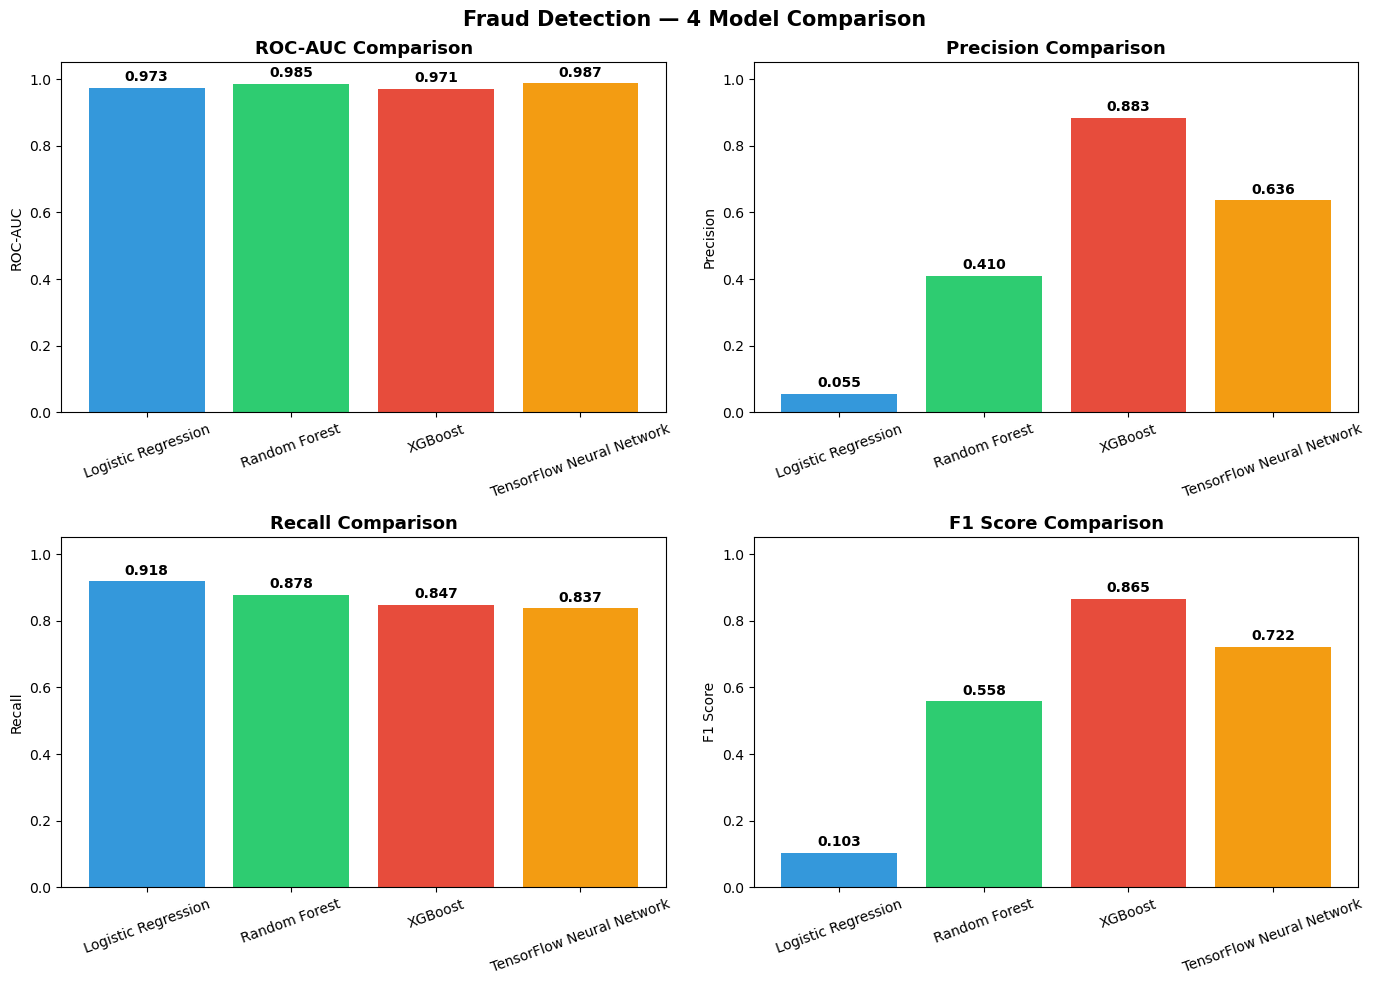

Saved: output/model_comparison_chart.png
BEST MODEL: TensorFlow Neural Network
BEST ROC-AUC: 0.9872


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, nn_metrics])
print("MODEL COMPARISON")
print(comparison_df.to_string(index=False))

os.makedirs('output', exist_ok=True)
comparison_df.to_csv('output/model_comparison.csv', index=False)
print("Saved: output/model_comparison.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = comparison_df['model'].values
metrics_names = ['roc_auc', 'precision', 'recall', 'f1']
metric_labels = ['ROC-AUC', 'Precision', 'Recall', 'F1 Score']
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12']

for ax, metric, label in zip(axes.flatten(), metrics_names, metric_labels):
    values = comparison_df[metric].values
    bars = ax.bar(models, values, color=colors)
    ax.set_title(f'{label} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Fraud Detection — 4 Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('output/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: output/model_comparison_chart.png")

best_model_idx = comparison_df['roc_auc'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'model']
best_auc = comparison_df.loc[best_model_idx, 'roc_auc']

print(f"BEST MODEL: {best_model}")
print(f"BEST ROC-AUC: {best_auc:.4f}")

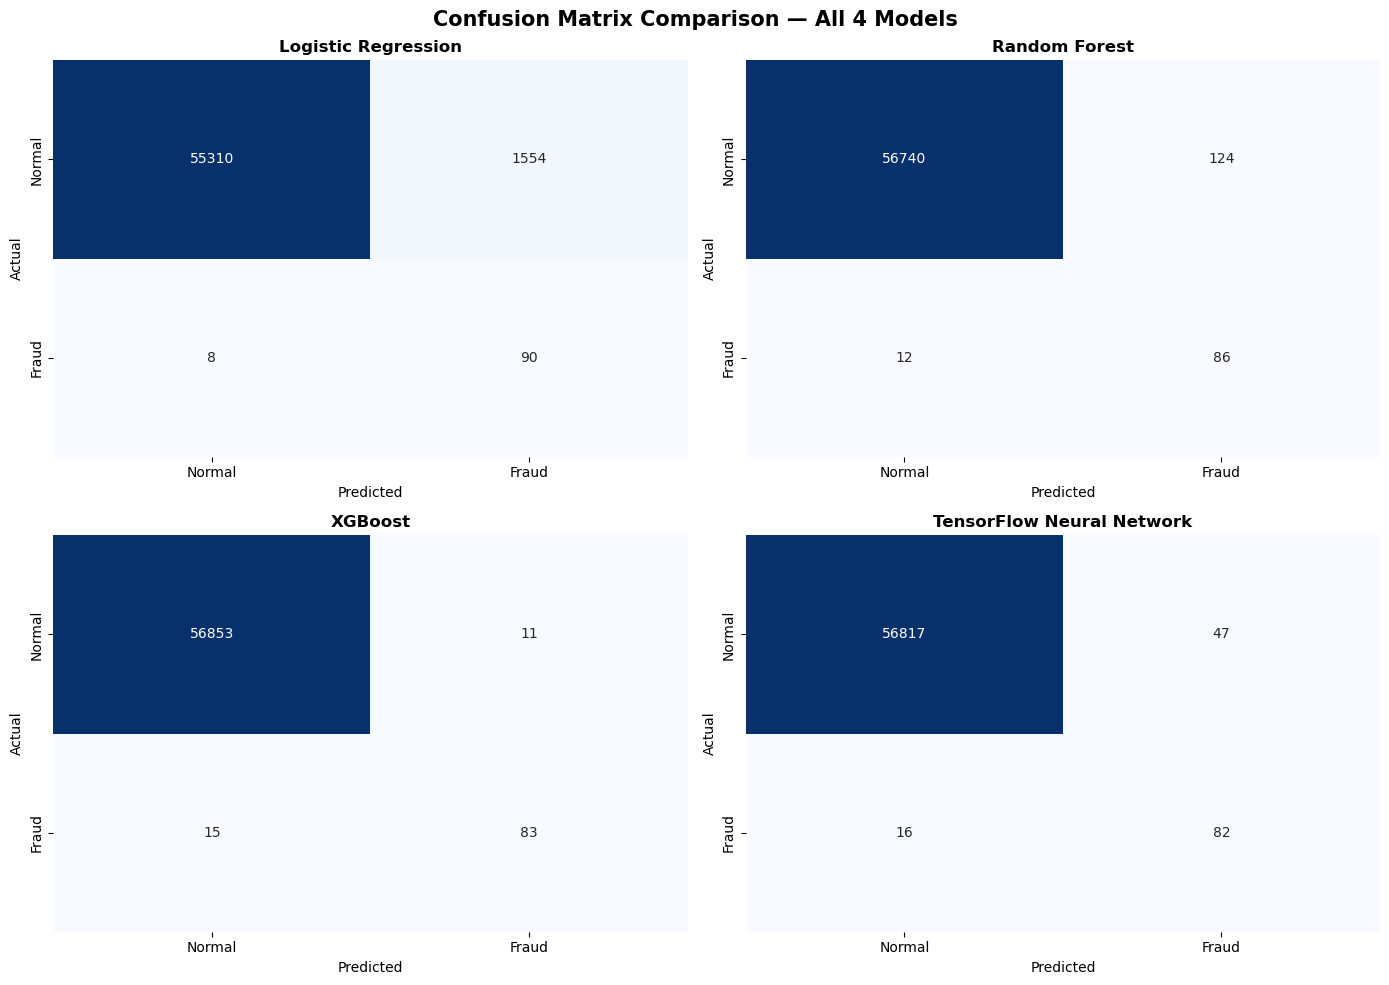

Saved: output/confusion_matrix_comparison.png
All Deep Learning extension files saved to output/


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

confusion_data = [
    (y_test, y_pred_lr, 'Logistic Regression'),
    (y_test, y_pred_rf, 'Random Forest'),
    (y_test, y_pred_xgb, 'XGBoost'),
    (y_test, y_pred_nn, 'TensorFlow Neural Network')
]

for ax, (y_true, y_pred, name) in zip(axes.flatten(), confusion_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'], ax=ax, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison — All 4 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('output/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: output/confusion_matrix_comparison.png")
print("All Deep Learning extension files saved to output/")